# 1. Autoencoder Baseline

**Objective:** Train the default vanilla autoencoder and evaluate it as
an unsupervised anomaly detector. This notebook documents the full
pipeline end-to-end for a single configuration.

**Architecture:** Encoder [16 → 64 → 32 → 16] → Decoder [16 → 32 → 64 → 16]

**Key idea:** Train only on normal transactions. At inference, fraud
produces higher reconstruction error because the model has never seen
fraud patterns — it only knows how to reconstruct normal ones.

## 1.1 Setup and Data Loading

In [2]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.train import train_autoencoder
from src.evaluate import (compute_reconstruction_errors, evaluate,
                          find_threshold_by_percentile, find_threshold_by_f1)
from src.utils import (get_device, set_seed, plot_training_curves,
                       plot_reconstruction_error_distribution,
                       plot_precision_recall_curve, plot_threshold_sweep,
                       plot_confusion_matrix)
from src.dataset import NormalOnlyDataset, FraudDataset

set_seed(42)
device = get_device()
print(f"Device: {device}")

data = load_processed("../data/processed", "../models")
print(f"Train: {data['x_train'].shape} (all normal)")
print(f"Val:   {data['x_val'].shape} (fraud rate: {data['y_val'].mean():.2%})")
print(f"Test:  {data['x_test'].shape} (fraud rate: {data['y_test'].mean():.2%})")
print(f"Input dim: {data['input_dim']}")
print(f"Features: {data['feature_names']}")

Device: mps
Train: (979379, 16) (all normal)
Val:   (246786, 16) (fraud rate: 14.96%)
Test:  (246787, 16) (fraud rate: 14.96%)
Input dim: 16
Features: ['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Address Match', 'Hour_Sin', 'Hour_Cos', 'Payment Method_bank transfer', 'Payment Method_credit card', 'Payment Method_debit card', 'Product Category_electronics', 'Product Category_health & beauty', 'Product Category_home & garden', 'Product Category_toys & games', 'Device Used_mobile', 'Device Used_tablet']


## 1.2 Build Data Loaders

Training uses **normal transactions only**. The autoencoder learns to
reconstruct the "normal" manifold. Validation for training loss uses
normal-only samples too. The full val/test sets (with fraud) are used
only for anomaly detection evaluation.

In [3]:
# Training: normal-only (x_train is already normal-only from preprocessing)
train_ds = NormalOnlyDataset(data["x_train"])

# Validation: normal-only for MSE tracking
val_normal_mask = data["y_val"] == 0
val_normal_ds = NormalOnlyDataset(data["x_val"][val_normal_mask])

# Full val/test with fraud labels for evaluation
val_full_ds = FraudDataset(data["x_val"], data["y_val"])
test_full_ds = FraudDataset(data["x_test"], data["y_test"])

BATCH_SIZE = 1024
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_normal_loader = DataLoader(val_normal_ds, batch_size=BATCH_SIZE)
val_full_loader = DataLoader(val_full_ds, batch_size=BATCH_SIZE)
test_full_loader = DataLoader(test_full_ds, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}")
print(f"Val (normal) batches: {len(val_normal_loader)}")
print(f"Val (full) batches: {len(val_full_loader)}")
print(f"Test batches: {len(test_full_loader)}")

Train batches: 957
Val (normal) batches: 205
Val (full) batches: 242
Test batches: 242


## 1.3 Build Model

Architecture: fully connected symmetric autoencoder.
Each encoder layer: 
Final decoder layer:  (no activation — reconstructs raw scaled features).

In [4]:
HIDDEN_DIMS = [64, 32, 16]
DROPOUT = 0.2

model = build_autoencoder(
    model_type="vanilla",
    input_dim=data["input_dim"],
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Bottleneck dimension: {HIDDEN_DIMS[-1]}")
print(f"Trainable parameters: {n_params:,}")
print(model)

Bottleneck dimension: 16
Trainable parameters: 7,808
FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, m

## 1.4 Training

Loss: MSE between input and reconstruction.
Optimizer: Adam (lr=1e-3, weight_decay=1e-5).
Scheduler: ReduceLROnPlateau (halves LR after 5 epochs without improvement).
Early stopping: patience 10, restores best weights.

In [5]:
history = train_autoencoder(
    model, train_loader, val_normal_loader, device,
    epochs=100, lr=1e-3, weight_decay=1e-5, patience=10,
)

print(f"Best epoch: {history['best_epoch']}")
print(f"Best val MSE: {history['best_val_loss']:.6f}")
print(f"Training time: {history['wall_time_sec']:.1f}s")

  Epoch   1/100  | Train MSE: 0.500287  | Val MSE: 0.248411  | LR: 1.00e-03
  Epoch   5/100  | Train MSE: 0.306437  | Val MSE: 0.177842  | LR: 1.00e-03
  Epoch  10/100  | Train MSE: 0.272508  | Val MSE: 0.147449  | LR: 1.00e-03
  Epoch  15/100  | Train MSE: 0.265528  | Val MSE: 0.140223  | LR: 1.00e-03
  Epoch  20/100  | Train MSE: 0.256480  | Val MSE: 0.120588  | LR: 1.00e-03
  Epoch  25/100  | Train MSE: 0.245750  | Val MSE: 0.109199  | LR: 1.00e-03
  Epoch  30/100  | Train MSE: 0.242077  | Val MSE: 0.101631  | LR: 1.00e-03
  Epoch  35/100  | Train MSE: 0.239837  | Val MSE: 0.103366  | LR: 1.00e-03
  Epoch  40/100  | Train MSE: 0.239104  | Val MSE: 0.102894  | LR: 1.00e-03
  Epoch  45/100  | Train MSE: 0.238144  | Val MSE: 0.099167  | LR: 1.00e-03
  Epoch  50/100  | Train MSE: 0.237529  | Val MSE: 0.101261  | LR: 1.00e-03
  Epoch  55/100  | Train MSE: 0.237241  | Val MSE: 0.100067  | LR: 1.00e-03
  Epoch  60/100  | Train MSE: 0.234807  | Val MSE: 0.099107  | LR: 5.00e-04
  Epoch  65/

Saved: ../figures/fig01_baseline_training_curves.png


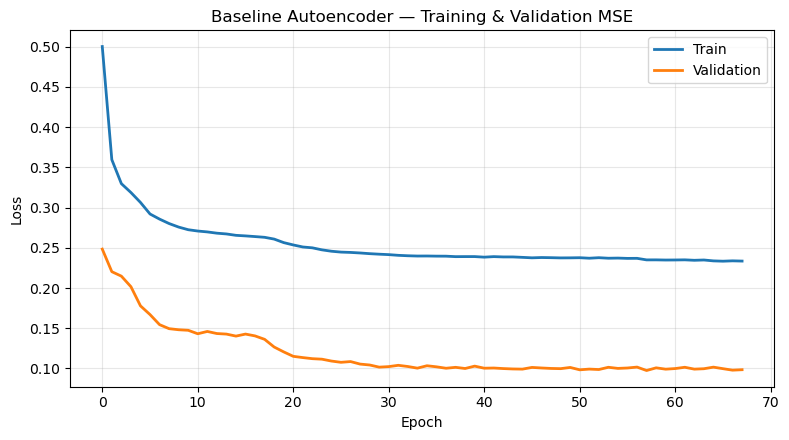

In [6]:
plot_training_curves(
    history,
    save_path="../figures/fig01_baseline_training_curves.png",
    title="Baseline Autoencoder — Training & Validation MSE",
)

## 1.5 Threshold Selection

Two threshold methods compared:
1. **Unsupervised (percentile):** Flag anything above the 95th percentile
   of normal reconstruction errors. No fraud labels needed.
2. **F1-optimal:** Use fraud labels on the val set to find the threshold
   that maximizes F1. This is semi-supervised and serves as an upper bound.

In [7]:
# Compute reconstruction errors on the full val set (normal + fraud)
val_errors, val_labels = compute_reconstruction_errors(model, val_full_loader, device)
normal_val_errors = val_errors[val_labels == 0]

print("--- Unsupervised threshold (95th percentile) ---")
threshold_pct = find_threshold_by_percentile(normal_val_errors, percentile=95.0)

print("--- F1-optimal threshold (uses fraud labels) ---")
threshold_f1 = find_threshold_by_f1(val_errors, val_labels)

--- Unsupervised threshold (95th percentile) ---
Threshold at 95.0th percentile of normal errors: 0.227661
--- F1-optimal threshold (uses fraud labels) ---
F1-optimal threshold: 0.139795  (precision=0.262, recall=0.368, f1=0.306)


Saved: ../figures/fig02_baseline_error_distribution.png


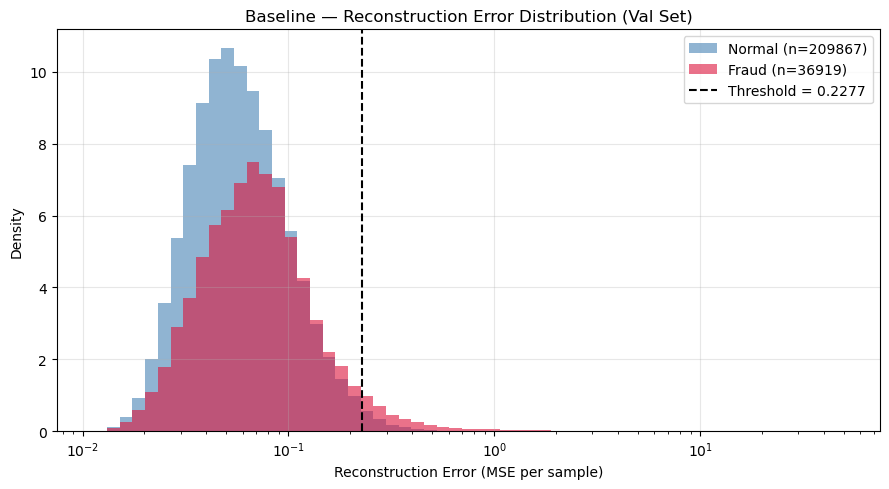

In [8]:
plot_reconstruction_error_distribution(
    val_errors, val_labels, threshold=threshold_pct,
    save_path="../figures/fig02_baseline_error_distribution.png",
    title="Baseline — Reconstruction Error Distribution (Val Set)",
)

Saved: ../figures/fig03_baseline_threshold_sweep.png


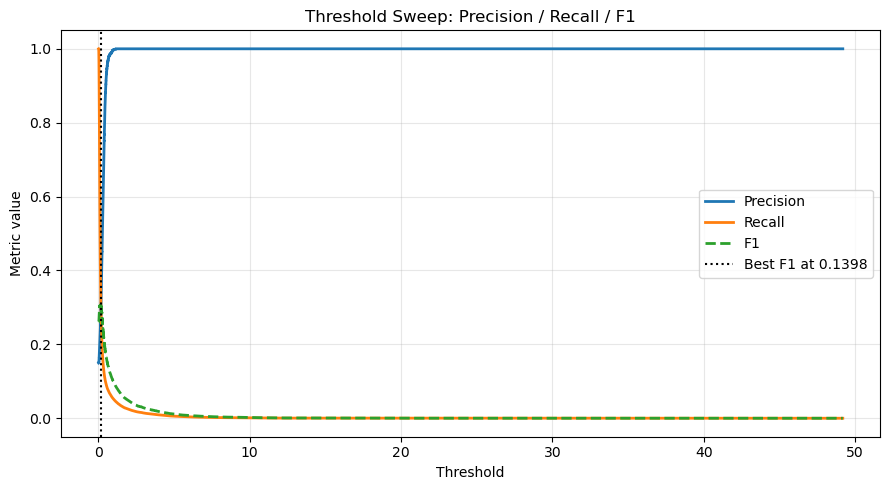

In [9]:
plot_threshold_sweep(
    val_errors, val_labels,
    save_path="../figures/fig03_baseline_threshold_sweep.png",
)

## 1.6 Test Set Evaluation

Final evaluation on the **held-out test set**, which the model has never
seen during training or threshold selection.

In [10]:
test_errors, test_labels = compute_reconstruction_errors(model, test_full_loader, device)

print("=== Unsupervised threshold ===")
metrics_pct = evaluate(test_errors, test_labels, threshold_pct, label="Test (95th pct)")

print("=== F1-optimal threshold ===")
metrics_f1 = evaluate(test_errors, test_labels, threshold_f1, label="Test (F1-opt)")

=== Unsupervised threshold ===

  Test (95th pct) Set Evaluation   (threshold = 0.227661)
              precision    recall  f1-score   support

      Normal     0.8716    0.9503    0.9093    209868
       Fraud     0.4198    0.2043    0.2749     36919

    accuracy                         0.8387    246787
   macro avg     0.6457    0.5773    0.5921    246787
weighted avg     0.8040    0.8387    0.8144    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199443        10425
  True Fraud          29375         7544

  ROC-AUC:  0.6392
  PR-AUC:   0.3327  (better metric for imbalanced data)
  F1:       0.2749
=== F1-optimal threshold ===

  Test (F1-opt) Set Evaluation   (threshold = 0.139795)
              precision    recall  f1-score   support

      Normal     0.8798    0.8158    0.8466    209868
       Fraud     0.2594    0.3666    0.3038     36919

    accuracy                         0.7486    246787
   macro avg     0.5696    0.5912    0.5752

Saved: ../figures/fig04_baseline_confusion_matrix.png


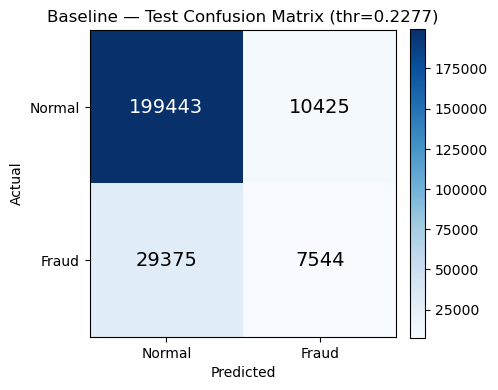

In [11]:
test_preds_pct = (test_errors >= threshold_pct).astype(int)
plot_confusion_matrix(
    test_labels, test_preds_pct,
    save_path="../figures/fig04_baseline_confusion_matrix.png",
    title=f"Baseline — Test Confusion Matrix (thr={threshold_pct:.4f})",
)

Saved: ../figures/fig05_baseline_pr_curve.png


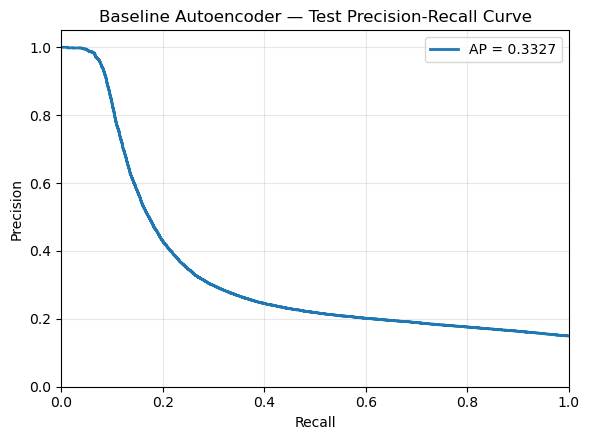

In [12]:
plot_precision_recall_curve(
    test_errors, test_labels,
    save_path="../figures/fig05_baseline_pr_curve.png",
    title="Baseline Autoencoder — Test Precision-Recall Curve",
)

## 1.7 Error Analysis (Failure Cases)

Rubric requirement: *"show examples of your model malfunctioning and discuss
what might be the reason for such problems."*

We examine the worst false negatives (missed fraud) and false positives
(legitimate transactions flagged as fraud).

In [13]:
from src.evaluate import get_failure_cases

failures = get_failure_cases(
    test_errors, test_labels, data["x_test"],
    threshold=threshold_pct,
    feature_names=data["feature_names"],
    n_examples=10,
)

print("=== FALSE NEGATIVES (Missed Fraud) ===")
print("These are fraudulent transactions the model scored as normal.")
print("Low reconstruction error means the fraud looked like a normal transaction.")
print()
if "false_negatives" in failures:
    display(failures["false_negatives"])
else:
    print("No false negatives found.")

=== FALSE NEGATIVES (Missed Fraud) ===
These are fraudulent transactions the model scored as normal.
Low reconstruction error means the fraud looked like a normal transaction.



,Transaction Amount,Quantity,Customer Age,Account Age Days,Address Match,Hour_Sin,Hour_Cos,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_mobile,Device Used_tablet,score,true_label
0,-0.278785,0.705179,0.249111,-0.769259,0.333963,-1.003483,0.996402,-0.576939,-0.577382,1.731262,-0.500442,-0.500807,2.004073,-0.499549,1.413638,-0.706815,0.013450,1.0
1,-0.424441,-0.001925,-0.150913,0.285050,0.333963,0.703779,1.221129,-0.576939,-0.577382,1.731262,-0.500442,-0.500807,-0.498984,2.001806,-0.707395,-0.706815,0.014479,1.0
2,-0.428341,-0.001925,0.049099,0.532005,0.333963,0.703779,1.221129,-0.576939,1.731955,-0.577613,-0.500442,-0.500807,-0.498984,2.001806,-0.707395,1.414797,0.014693,1.0
3,-0.162780,0.705179,0.349117,0.892940,0.333963,-1.003483,0.996402,1.733286,-0.577382,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,0.014757,1.0
4,-0.157379,-0.001925,-0.050907,-0.949727,0.333963,0.703779,1.221129,1.733286,-0.577382,-0.577613,-0.500442,-0.500807,-0.498984,2.001806,1.413638,-0.706815,0.014862,1.0
5,-0.249284,-0.001925,-0.250918,-0.826249,0.333963,0.362667,1.362399,-0.576939,1.731955,-0.577613,-0.500442,-0.500807,-0.498984,2.001806,1.413638,-0.706815,0.015399,1.0
6,-0.423191,-0.001925,-0.150913,0.816954,0.333963,-1.003483,0.996402,-0.576939,-0.577382,1.731262,-0.500442,-0.500807,-0.498984,2.001806,-0.707395,1.414797,0.015440,1.0
7,-0.158280,-0.709028,-0.350924,-0.740764,0.333963,1.362758,-0.369515,-0.576939,-0.577382,1.731262,-0.500442,-0.500807,-0.498984,2.001806,-0.707395,-0.706815,0.015626,1.0
8,-0.486844,0.705179,0.549128,-0.655280,0.333963,0.996699,0.996402,-0.576939,-0.577382,1.731262,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,0.015796,1.0
9,-0.439042,0.705179,0.149105,-0.759761,0.333963,0.703779,1.221129,-0.576939,1.731955,-0.577613,-0.500442,-0.500807,-0.498984,2.001806,1.413638,-0.706815,0.016009,1.0


In [14]:
print("=== FALSE POSITIVES (False Alarms) ===")
print("These are legitimate transactions the model flagged as fraud.")
print("High reconstruction error means the transaction was unusual but not actually fraudulent.")
print()
if "false_positives" in failures:
    display(failures["false_positives"])
else:
    print("No false positives found.")

=== FALSE POSITIVES (False Alarms) ===
These are legitimate transactions the model flagged as fraud.
High reconstruction error means the transaction was unusual but not actually fraudulent.



,Transaction Amount,Quantity,Customer Age,Account Age Days,Address Match,Hour_Sin,Hour_Cos,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_mobile,Device Used_tablet,score,true_label
0,16.805618,0.705179,1.049157,1.453339,0.333963,0.362667,1.362399,-0.576939,1.731955,-0.577613,1.998233,-0.500807,-0.498984,-0.499549,-0.707395,1.414797,3.104448,0.0
1,1.520144,0.705179,-4.651175,-0.085383,0.333963,-0.003392,-1.417620,1.733286,-0.577382,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,2.015485,0.0
2,11.670391,-0.709028,0.049099,1.681298,0.333963,-0.710563,-1.228166,-0.576939,-0.577382,1.731262,1.998233,-0.500807,-0.498984,-0.499549,-0.707395,-0.706815,1.320128,0.0
3,10.577192,0.705179,0.949152,0.949930,0.333963,1.362758,0.362478,-0.576939,1.731955,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,1.193417,0.0
4,0.369644,1.412282,-3.851128,-0.921232,0.333963,0.362667,1.362399,-0.576939,-0.577382,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,-0.707395,1.414797,1.163401,0.0
5,9.953266,1.412282,-0.650942,-0.341836,0.333963,0.362667,-1.369436,-0.576939,-0.577382,1.731262,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,1.160733,0.0
6,10.602844,1.412282,1.149163,-0.066386,0.333963,1.362758,0.362478,-0.576939,-0.577382,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,-0.707395,1.414797,1.129357,0.0
7,9.350789,-0.001925,-3.051081,-1.253671,0.333963,-1.228249,0.703532,-0.576939,1.731955,-0.577613,1.998233,-0.500807,-0.498984,-0.499549,-0.707395,-0.706815,1.079580,0.0
8,8.641308,-1.416131,1.549186,0.873944,0.333963,0.996699,-1.003439,-0.576939,-0.577382,1.731262,-0.500442,-0.500807,-0.498984,2.001806,-0.707395,1.414797,1.043672,0.0
9,10.861606,0.705179,0.649134,1.519827,0.333963,-1.369542,0.362478,-0.576939,1.731955,-0.577613,-0.500442,-0.500807,2.004073,-0.499549,-0.707395,1.414797,1.004951,0.0


## 1.8 Save Model

Save the trained model, threshold, and metadata for reproducibility.

In [15]:
from src.utils import save_checkpoint

metadata = {
    "model_type": "vanilla",
    "input_dim": data["input_dim"],
    "hidden_dims": HIDDEN_DIMS,
    "dropout": DROPOUT,
    "threshold_unsupervised": float(threshold_pct),
    "threshold_f1_optimal": float(threshold_f1),
    "best_epoch": history["best_epoch"],
    "best_val_loss": history["best_val_loss"],
    "test_pr_auc": metrics_pct["pr_auc"],
    "test_f1": metrics_pct["f1"],
}

# Save as baseline checkpoint
save_checkpoint(model, path="../models/autoencoder_baseline.pt", metadata=metadata)

# Also save as autoencoder_best.pt so Notebook 4 works even
# if Notebook 2 (tuning) has not been run yet.
# Notebook 2 will overwrite this with the best tuned variant.
save_checkpoint(model, path="../models/autoencoder_best.pt", metadata=metadata)
print("Saved autoencoder_baseline.pt and autoencoder_best.pt")
print("Run Notebook 2 to find and save a better variant.")


Saved checkpoint to ../models/autoencoder_baseline.pt
Saved checkpoint to ../models/autoencoder_best.pt
Saved autoencoder_baseline.pt and autoencoder_best.pt
Run Notebook 2 to find and save a better variant.


In [16]:
# Auto-generated summary
print("=" * 55)
print("BASELINE AUTOENCODER — TEST RESULTS")
print("=" * 55)
print(f"Architecture:    {HIDDEN_DIMS}")
print(f"Dropout:         {DROPOUT}")
best_epoch = history["best_epoch"]
print(f"Best epoch:      {best_epoch}")
print()
p1 = metrics_pct["precision"]
r1 = metrics_pct["recall"]
f1 = metrics_pct["f1"]
a1 = metrics_pct["pr_auc"]
p2 = metrics_f1["precision"]
r2 = metrics_f1["recall"]
f2 = metrics_f1["f1"]
a2 = metrics_f1["pr_auc"]
fraud_rate = data["y_test"].mean()
improvement = a1 / fraud_rate
print(f"Threshold method   Precision   Recall     F1        PR-AUC")
print(f"Percentile-95      {p1:.4f}      {r1:.4f}     {f1:.4f}    {a1:.4f}")
print(f"F1-optimal         {p2:.4f}      {r2:.4f}     {f2:.4f}    {a2:.4f}")
print()
print(f"Random baseline (fraud rate): {fraud_rate:.4f}")
print(f"PR-AUC improvement over random: {improvement:.1f}x")

BASELINE AUTOENCODER — TEST RESULTS
Architecture:    [64, 32, 16]
Dropout:         0.2
Best epoch:      58

Threshold method   Precision   Recall     F1        PR-AUC
Percentile-95      0.4198      0.2043     0.2749    0.3327
F1-optimal         0.2594      0.3666     0.3038    0.3327

Random baseline (fraud rate): 0.1496
PR-AUC improvement over random: 2.2x
